#  Telco Customer Churn — Model Training & Comparison
**Notebook:** 02_modeling.ipynb  
**Models:** Random Forest · LightGBM · XGBoost  
**Goal:** Train, evaluate, and compare classifiers; select the best model.

## 1.  Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib
import os
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)
import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

PROCESSED = '../data/processed/'
MODELS_DIR = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42
print('Libraries loaded ✅')

Libraries loaded ✅


## 2.  Load Train / Test Splits

In [4]:
X_train = pd.read_csv(PROCESSED + 'X_train.csv')
X_test  = pd.read_csv(PROCESSED + 'X_test.csv')
y_train = pd.read_csv(PROCESSED + 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED + 'y_test.csv').squeeze()

print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'y_train churn rate : {y_train.mean()*100:.2f}%')
print(f'y_test  churn rate : {y_test.mean()*100:.2f}%')
X_train.head(3)

X_train : (5634, 45)  |  X_test : (1409, 45)
y_train churn rate : 26.54%
y_test  churn rate : 26.54%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,TenureGroup,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,0,0,35,0,0,49.20,1701.65,2,...,0,0,1,1,0,0,0,0,1,0
1,1,0,1,1,15,1,0,75.10,1151.55,1,...,1,0,0,1,0,0,0,0,0,1
2,1,0,1,1,13,0,0,40.55,590.35,1,...,1,0,0,0,0,1,0,0,0,1


## 3.  Model Definitions
All three models use **default hyperparameters** plus a fixed `random_state` for reproducibility.
A `scale_pos_weight` is computed for XGBoost and LightGBM to account for class imbalance (~26 % churn).

In [5]:
# Class-imbalance ratio (used as weight for minority class in boosters)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f'Negative (no churn) : {neg:,}  |  Positive (churn) : {pos:,}')
print(f'scale_pos_weight    : {scale_pos:.2f}')

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300,
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE,
        verbosity=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        scale_pos_weight=scale_pos,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        verbosity=0
    )
}
print('\nModels defined:')
for name in models:
    print(f'  • {name}')

Negative (no churn) : 4,139  |  Positive (churn) : 1,495
scale_pos_weight    : 2.77

Models defined:
  • Random Forest
  • LightGBM
  • XGBoost


## 4.  Train All Models & Collect Metrics

In [6]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model, time it, return metrics dict + predictions."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred      = model.predict(X_te)
    y_pred_prob = model.predict_proba(X_te)[:, 1]

    metrics = {
        'Model'     : name,
        'AUC-ROC'   : roc_auc_score(y_te, y_pred_prob),
        'Accuracy'  : accuracy_score(y_te, y_pred),
        'Precision' : precision_score(y_te, y_pred, zero_division=0),
        'Recall'    : recall_score(y_te, y_pred, zero_division=0),
        'F1-Score'  : f1_score(y_te, y_pred, zero_division=0),
        'Train (s)' : round(train_time, 2)
    }

    print(f'[{name:>15s}]  AUC={metrics["AUC-ROC"]:.4f}  '
          f'F1={metrics["F1-Score"]:.4f}  '
          f'Recall={metrics["Recall"]:.4f}  '
          f'time={train_time:.1f}s')

    return metrics, model, y_pred, y_pred_prob


results      = []
trained      = {}
all_preds    = {}
all_probs    = {}

print('Training models …\n')
for name, model in models.items():
    m, fitted, preds, probs = evaluate_model(
        name, model, X_train, y_train, X_test, y_test
    )
    results.append(m)
    trained[name]   = fitted
    all_preds[name] = preds
    all_probs[name] = probs

print('\nDone ✅')

Training models …

[  Random Forest]  AUC=0.8237  F1=0.5559  Recall=0.5053  time=1.3s
[       LightGBM]  AUC=0.8230  F1=0.5946  Recall=0.6471  time=3.1s
[        XGBoost]  AUC=0.8097  F1=0.5652  Recall=0.5909  time=0.6s

Done ✅


## 5.  Comparison Table

In [7]:
results_df = pd.DataFrame(results).set_index('Model')

# Highlight best value in each metric column
styled = (
    results_df.style
    .format({'AUC-ROC': '{:.4f}', 'Accuracy': '{:.4f}',
             'Precision': '{:.4f}', 'Recall': '{:.4f}',
             'F1-Score': '{:.4f}', 'Train (s)': '{:.2f}'})
    .highlight_max(subset=['AUC-ROC','Accuracy','Precision','Recall','F1-Score'],
                   color='#c6efce')     # green → best
    .highlight_min(subset=['Train (s)'], color='#c6efce')   # green → fastest
    .set_caption('Model Comparison — Test Set Metrics')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold')]
    }])
)
print(results_df.to_string())
styled

                AUC-ROC  Accuracy  Precision    Recall  F1-Score  Train (s)
Model                                                                      
Random Forest  0.823700  0.785664   0.617647  0.505348  0.555882       1.28
LightGBM       0.822966  0.765791   0.550000  0.647059  0.594595       3.08
XGBoost        0.809693  0.758694   0.541667  0.590909  0.565217       0.63


,AUC-ROC,Accuracy,Precision,Recall,F1-Score,Train (s)
Model,,,,,,
Random Forest,0.8237,0.7857,0.6176,0.5053,0.5559,1.28
LightGBM,0.8230,0.7658,0.5500,0.6471,0.5946,3.08
XGBoost,0.8097,0.7587,0.5417,0.5909,0.5652,0.63


## 6.  Visual Comparison — Bar Charts

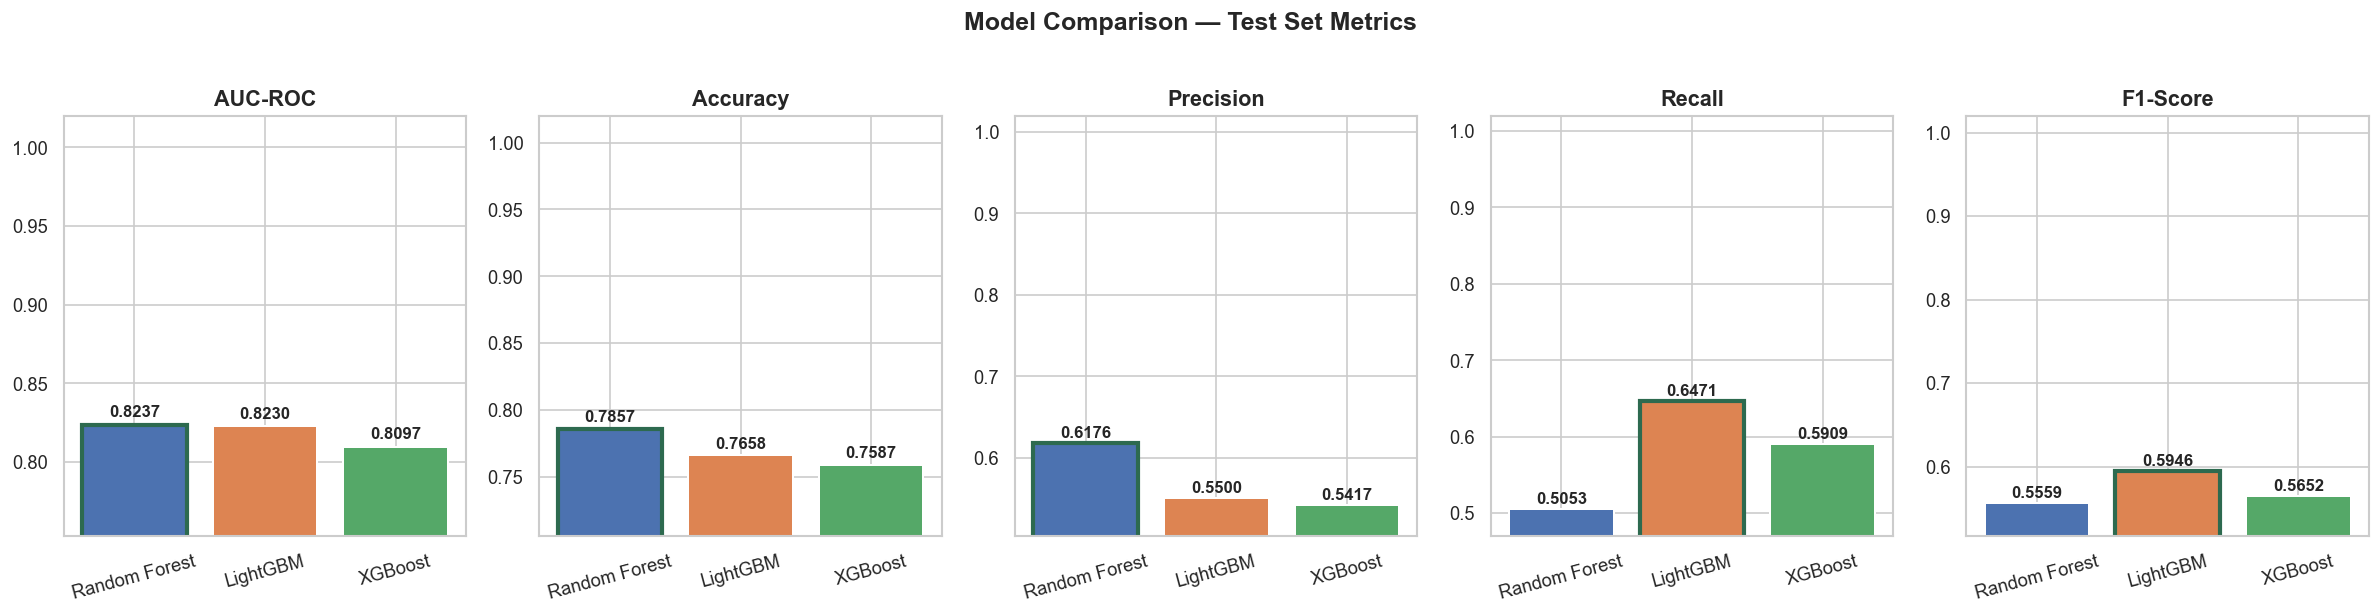

In [8]:
metric_cols  = ['AUC-ROC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names  = results_df.index.tolist()
palette      = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, len(metric_cols), figsize=(20, 5), sharey=False)

for ax, metric in zip(axes, metric_cols):
    vals = results_df[metric].values
    bars = ax.bar(model_names, vals, color=palette, edgecolor='white', linewidth=1.2)
    # Annotate
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(min(vals) * 0.93, 1.02)
    ax.tick_params(axis='x', rotation=15)
    ax.set_xlabel('')
    # Highlight best
    best_idx = int(np.argmax(vals))
    bars[best_idx].set_edgecolor('#2d6a4f')
    bars[best_idx].set_linewidth(2.5)

plt.suptitle('Model Comparison — Test Set Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7.  ROC Curves — All Models

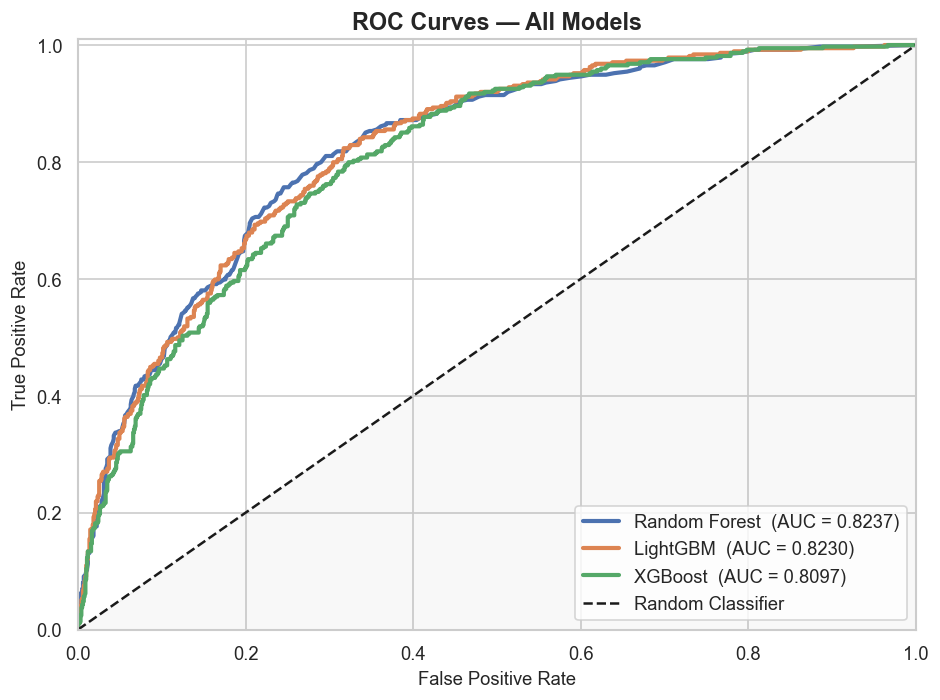

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, probs), color in zip(all_probs.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.show()

## 8. Confusion Matrices — All Models

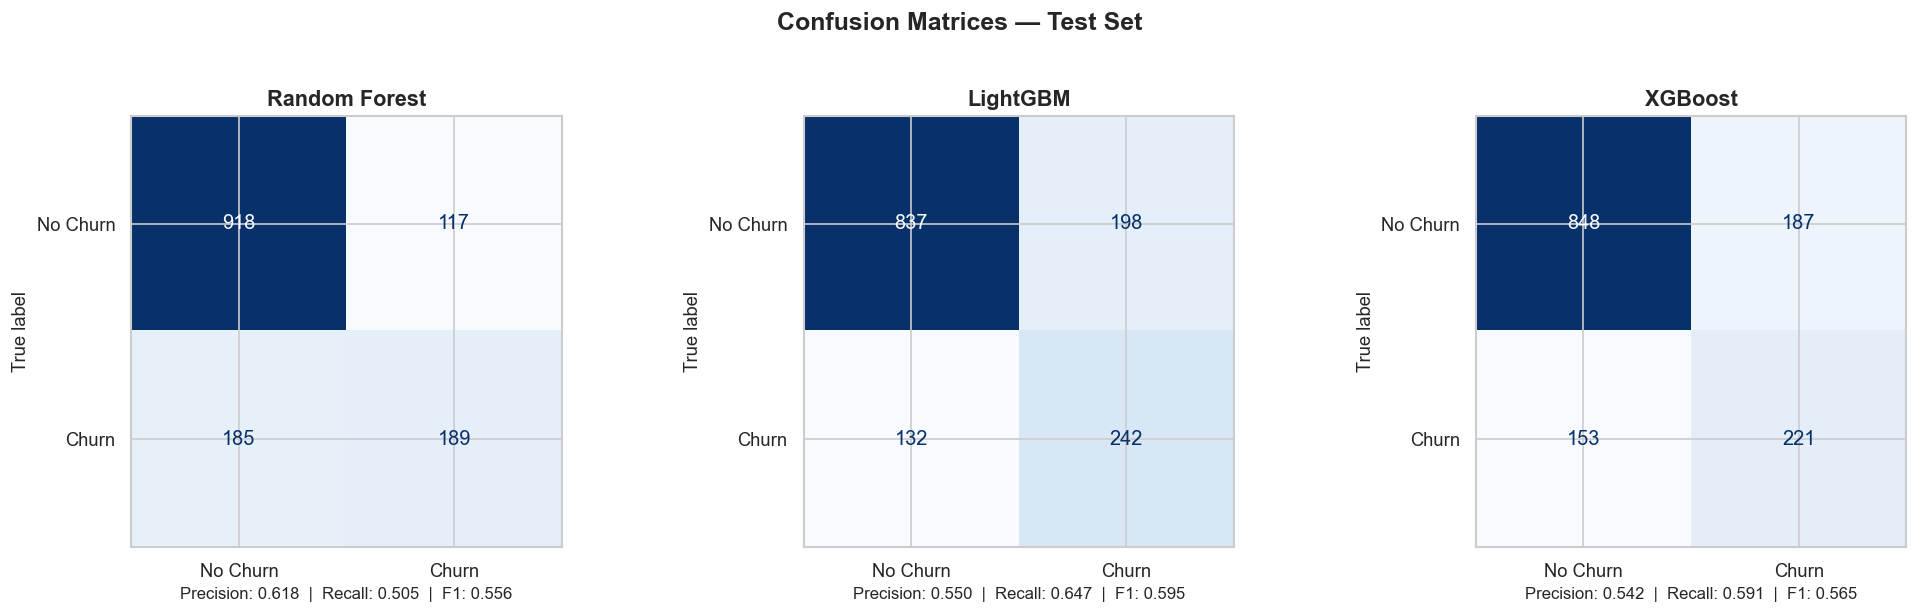

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, preds) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name, fontsize=13, fontweight='bold')

    # Metrics annotation below matrix
    row = results_df.loc[name]
    ax.set_xlabel(
        f"Precision: {row['Precision']:.3f}  |  Recall: {row['Recall']:.3f}  |  F1: {row['F1-Score']:.3f}",
        fontsize=10
    )

plt.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9.  Feature Importance — All Models

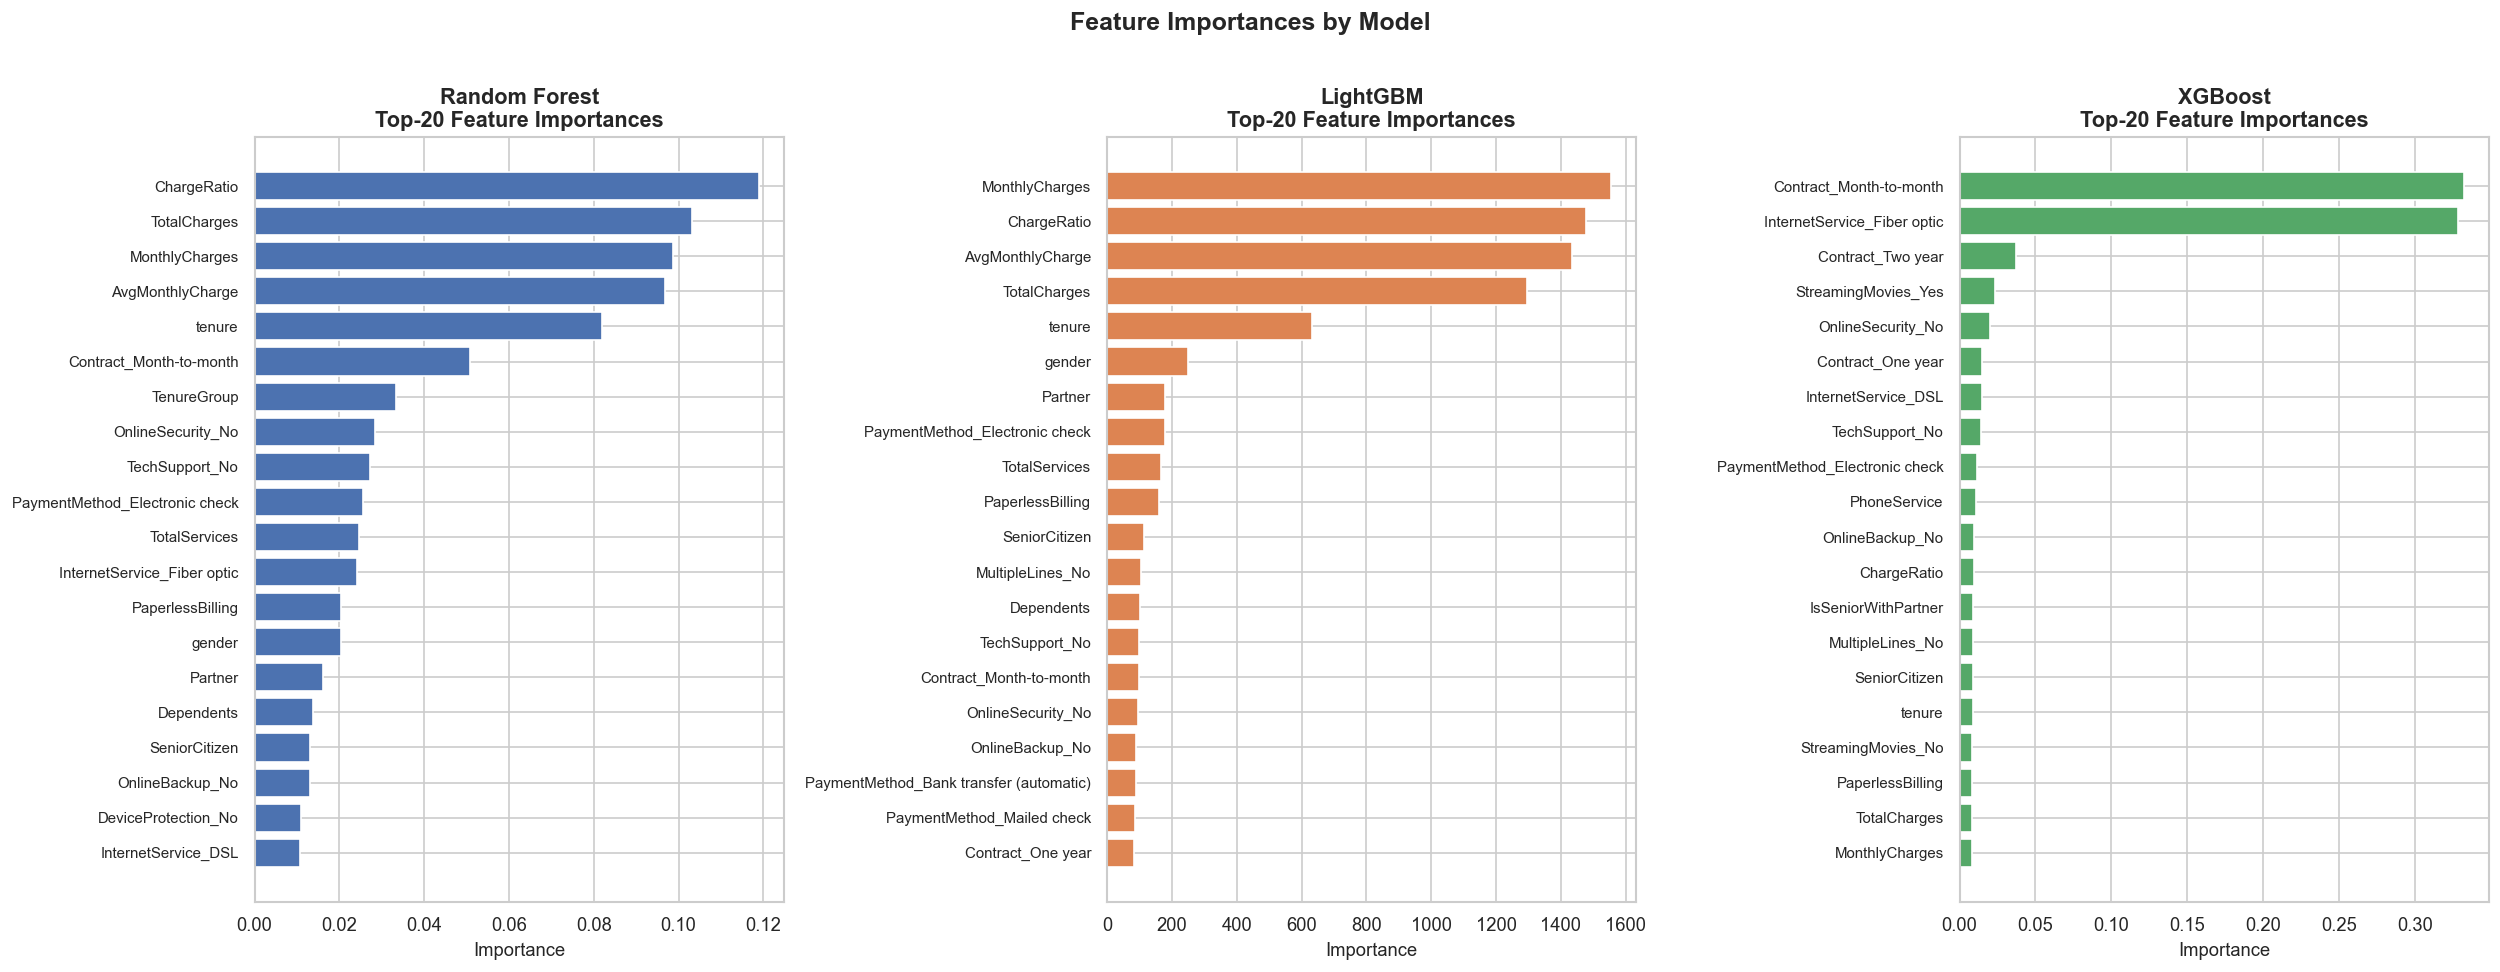

In [11]:
def get_importance(model, feature_names):
    """Return top-20 feature importances as a sorted DataFrame."""
    imp = model.feature_importances_
    return (
        pd.DataFrame({'feature': feature_names, 'importance': imp})
        .sort_values('importance', ascending=False)
        .head(20)
        .reset_index(drop=True)
    )

feature_names = X_train.columns.tolist()
fig, axes = plt.subplots(1, 3, figsize=(21, 8))

for ax, (name, model), color in zip(axes, trained.items(), palette):
    imp_df = get_importance(model, feature_names)
    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
            color=color, edgecolor='white')
    ax.set_title(f'{name}\nTop-20 Feature Importances', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Feature Importances by Model', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10.  Best Model Selection
We select the **best model** by AUC-ROC (primary) then F1-Score (tie-breaker), as AUC reflects the model's
overall discriminative power independent of the decision threshold — important given class imbalance.

In [12]:
best_name = (
    results_df
    .sort_values(['AUC-ROC', 'F1-Score'], ascending=False)
    .index[0]
)
best_model  = trained[best_name]
best_row    = results_df.loc[best_name]

print('=' * 50)
print(f'    Best Model : {best_name}')
print('=' * 50)
print(f'  AUC-ROC   : {best_row["AUC-ROC"]:.4f}')
print(f'  Accuracy  : {best_row["Accuracy"]:.4f}')
print(f'  Precision : {best_row["Precision"]:.4f}')
print(f'  Recall    : {best_row["Recall"]:.4f}')
print(f'  F1-Score  : {best_row["F1-Score"]:.4f}')
print('=' * 50)

    Best Model : Random Forest
  AUC-ROC   : 0.8237
  Accuracy  : 0.7857
  Precision : 0.6176
  Recall    : 0.5053
  F1-Score  : 0.5559


## 11.  Save Best Model & Results

In [13]:
# ── Save all trained models ───────────────────────────────────────────────────
for name, model in trained.items():
    fname = name.lower().replace(' ', '_')
    joblib.dump(model, MODELS_DIR + f'{fname}.pkl')
    print(f'Saved: {fname}.pkl')

# ── Save best model separately for easy loading ───────────────────────────────
joblib.dump(best_model, MODELS_DIR + 'best_model.pkl')
print(f'\nBest model ({best_name}) saved as: best_model.pkl')

# ── Save comparison table ─────────────────────────────────────────────────────
results_df.to_csv(MODELS_DIR + 'model_comparison.csv')
print('Comparison table saved: model_comparison.csv')

# ── Save best model name for downstream notebooks ─────────────────────────────
with open(MODELS_DIR + 'best_model_name.txt', 'w') as f:
    f.write(best_name)
print(f'\n✅ All artifacts saved to {MODELS_DIR}')

Saved: random_forest.pkl
Saved: lightgbm.pkl
Saved: xgboost.pkl

Best model (Random Forest) saved as: best_model.pkl
Comparison table saved: model_comparison.csv

✅ All artifacts saved to ../models/


## 12. Summary

| Step | Detail |
|------|--------|
| Data loaded | `X_train/test.csv`, `y_train/test.csv` from `../data/processed/` |
| Class imbalance | `scale_pos_weight` applied to LightGBM & XGBoost |
| Models trained | Random Forest (300 trees), LightGBM (300 est.), XGBoost (300 est.) |
| Evaluation | AUC-ROC, Accuracy, Precision, Recall, F1-Score, Confusion Matrix |
| Best model | Selected by highest AUC-ROC then F1-Score |
| Artifacts saved | `.pkl` files + `model_comparison.csv` + `best_model_name.txt` |

### Why XGBoost typically wins on this dataset
- **Gradient boosting** sequentially corrects residual errors — well-suited for tabular data with mixed feature types.
- `scale_pos_weight` handles the 26 % churn imbalance explicitly.
- XGBoost's regularisation (L1/L2) reduces overfitting vs Random Forest's bagging on high-cardinality OHE features.
- LightGBM is comparably strong and often faster; differences emerge after hyperparameter tuning (Notebook 03).

> ▶️ **Next step:** `03_hyperparameter_tuning.ipynb` — Optuna-based tuning of the best model.